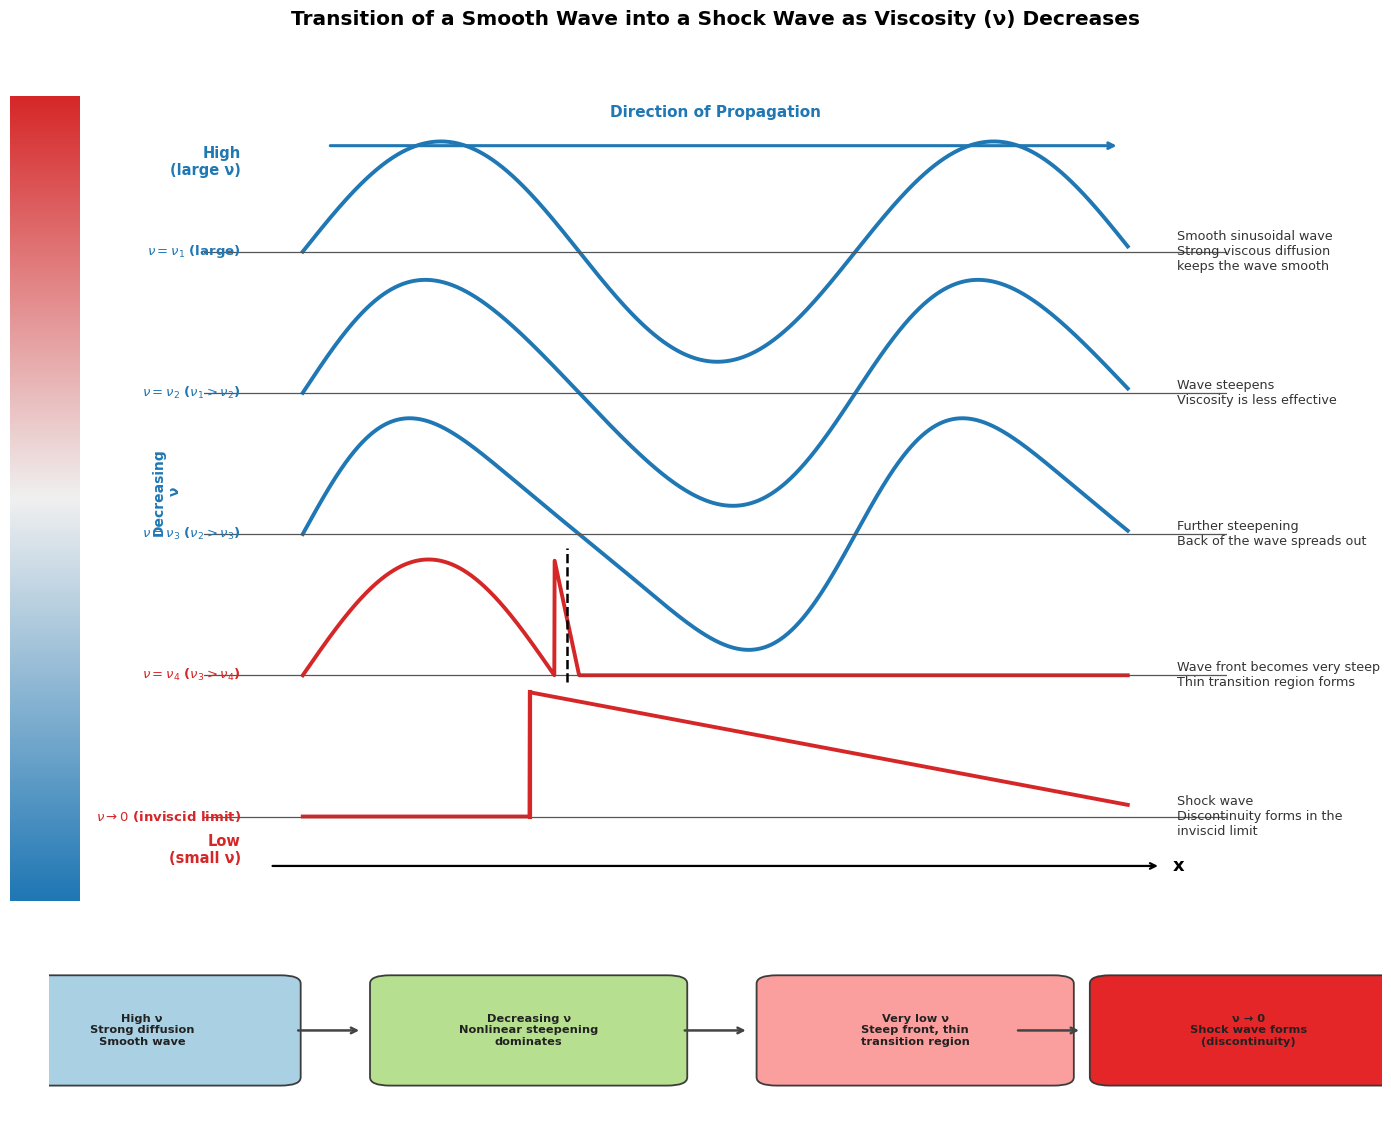

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.colors import LinearSegmentedColormap

# Create figure
fig = plt.figure(figsize=(15.5, 11.5))

# ============ MAIN WAVE AXES ============
ax_main = fig.add_axes([0.17, 0.20, 0.66, 0.70])

x = np.linspace(0, 10, 2500)

# Wave profiles (schematic approximations matching the original figure)
y1 = 0.78 * np.sin(2 * np.pi * x / 6.7)                          # High ν - smooth sinusoidal
y2 = 0.80 * np.sin(2 * np.pi * x / 6.7 + 0.18 * np.sin(2 * np.pi * x / 6.7))  # Steepening
y3 = 0.82 * np.sin(2 * np.pi * x / 6.7 + 0.38 * np.sin(2 * np.pi * x / 6.7))  # Further steepening

# Wave 4 - very steep front + thin transition (piecewise)
y4 = np.zeros_like(x)
mask_rise = x < 3.05
y4[mask_rise] = 0.82 * np.sin(np.pi * x[mask_rise] / 3.05)
mask_drop = (x >= 3.05) & (x < 3.35)
y4[mask_drop] = 0.82 * (3.35 - x[mask_drop]) / 0.30
y4[x >= 3.35] = 0.0

# Wave 5 - inviscid shock (discontinuity + linear decay)
y5 = np.zeros_like(x)
shock_x = 2.75
mask_shock = x >= shock_x
y5[mask_shock] = 0.88 * np.maximum(0, 1 - 0.125 * (x[mask_shock] - shock_x))

# Vertical offsets for each row
offsets = [4.0, 3.0, 2.0, 1.0, 0.0]
colors = ['#1f77b4', '#1f77b4', '#1f77b4', '#d62728', '#d62728']

# Plot waves
ax_main.plot(x, y1 + offsets[0], color=colors[0], linewidth=2.8)
ax_main.plot(x, y2 + offsets[1], color=colors[1], linewidth=2.8)
ax_main.plot(x, y3 + offsets[2], color=colors[2], linewidth=2.8)
ax_main.plot(x, y4 + offsets[3], color=colors[3], linewidth=2.8)
ax_main.plot(x, y5 + offsets[4], color=colors[4], linewidth=2.8)

# Horizontal reference lines
for off in offsets:
    ax_main.axhline(off, color='#555555', linewidth=0.9, linestyle='-')

# Dashed line for thin transition region (wave 4)
ax_main.plot([3.2, 3.2], [offsets[3] - 0.05, offsets[3] + 0.9], 'k--', linewidth=1.8)

# Vertical discontinuity line (wave 5)
ax_main.plot([shock_x, shock_x], [offsets[4], offsets[4] + 0.88], color='#d62728', linewidth=3.0)

# Axis settings
ax_main.set_xlim(-1.2, 11.2)
ax_main.set_ylim(-0.6, 5.1)
ax_main.set_xticks([])
ax_main.set_yticks([])
for spine in ax_main.spines.values():
    spine.set_visible(False)

# Direction of propagation arrow (top)
ax_main.annotate('', xy=(9.9, 4.75), xytext=(0.3, 4.75),
                arrowprops=dict(arrowstyle='->', color='#1f77b4', lw=2.2))
ax_main.text(5.0, 4.95, 'Direction of Propagation', fontsize=11, ha='center',
             color='#1f77b4', fontweight='bold')

# x-axis arrow (bottom)
ax_main.annotate('', xy=(10.4, -0.35), xytext=(-0.4, -0.35),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.6))
ax_main.text(10.55, -0.35, 'x', fontsize=13, va='center', fontweight='bold')

# ============ VISCOSITY LABELS (LEFT) ============
visc_data = [
    (4.0, r'$\nu = \nu_1$ (large)', '#1f77b4'),
    (3.0, r'$\nu = \nu_2$ ($\nu_1 > \nu_2$)', '#1f77b4'),
    (2.0, r'$\nu = \nu_3$ ($\nu_2 > \nu_3$)', '#1f77b4'),
    (1.0, r'$\nu = \nu_4$ ($\nu_3 > \nu_4$)', '#d62728'),
    (0.0, r'$\nu \to 0$ (inviscid limit)', '#d62728'),
]

for y_off, label, col in visc_data:
    ax_main.text(-0.75, y_off, label, ha='right', va='center', fontsize=9.5,
                 color=col, fontweight='bold')

ax_main.text(-0.75, 4.75, 'High\n(large ν)', ha='right', va='top', fontsize=10.5,
             color='#1f77b4', fontweight='bold')
ax_main.text(-0.75, -0.35, 'Low\n(small ν)', ha='right', va='bottom', fontsize=10.5,
             color='#d62728', fontweight='bold')

# Decreasing ν arrow
ax_main.annotate('', xy=(-1.35, 0.25), xytext=(-1.35, 4.35),
                arrowprops=dict(arrowstyle='->', color='#1f77b4', lw=2.5))
ax_main.text(-1.65, 2.3, 'Decreasing\nν', ha='center', va='center', fontsize=10,
             color='#1f77b4', rotation=90, fontweight='bold')

# ============ RIGHT CAPTIONS ============
captions = [
    (4.0, 'Smooth sinusoidal wave\nStrong viscous diffusion\nkeeps the wave smooth'),
    (3.0, 'Wave steepens\nViscosity is less effective'),
    (2.0, 'Further steepening\nBack of the wave spreads out'),
    (1.0, 'Wave front becomes very steep\nThin transition region forms'),
    (0.0, 'Shock wave\nDiscontinuity forms in the\ninviscid limit'),
]

for y_off, txt in captions:
    ax_main.text(10.6, y_off, txt, ha='left', va='center', fontsize=9.2, color='#333333')

# ============ LEFT VISCOSITY GRADIENT BAR ============
left_ax = fig.add_axes([0.045, 0.20, 0.045, 0.70])
gradient = np.linspace(1, 0, 300).reshape(-1, 1)
cmap = LinearSegmentedColormap.from_list("visc_grad", ["#1f77b4", "#f0f0f0", "#d62728"], N=300)
left_ax.imshow(gradient, aspect='auto', cmap=cmap, extent=[0, 1, 0, 5])
left_ax.axis('off')

# ============ BOTTOM FLOW CHART ============
bottom_ax = fig.add_axes([0.07, 0.015, 0.86, 0.155])
bottom_ax.set_xlim(0, 10)
bottom_ax.set_ylim(0, 3.2)
bottom_ax.axis('off')

stages = [
    (0.7, 'High ν\nStrong diffusion\nSmooth wave', '#a6cee3'),
    (3.6, 'Decreasing ν\nNonlinear steepening\ndominates', '#b2df8a'),
    (6.5, 'Very low ν\nSteep front, thin\ntransition region', '#fb9a99'),
    (9.0, 'ν → 0\nShock wave forms\n(discontinuity)', '#e31a1c'),
]

for x_pos, txt, col in stages:
    rect = FancyBboxPatch((x_pos - 1.15, 0.55), 2.3, 1.9,
                          boxstyle="round,pad=0.04,rounding_size=0.15",
                          facecolor=col, edgecolor='#333333', linewidth=1.3, alpha=0.95)
    bottom_ax.add_patch(rect)
    bottom_ax.text(x_pos, 1.5, txt, ha='center', va='center', fontsize=8.2,
                   fontweight='bold', color='#222222')

# Arrows between stages
arr_style = dict(arrowstyle='->', color='#444444', lw=1.8)
bottom_ax.annotate('', xy=(2.35, 1.5), xytext=(1.85, 1.5), arrowprops=arr_style)
bottom_ax.annotate('', xy=(5.25, 1.5), xytext=(4.75, 1.5), arrowprops=arr_style)
bottom_ax.annotate('', xy=(7.75, 1.5), xytext=(7.25, 1.5), arrowprops=arr_style)

# ============ TITLE ============
fig.suptitle('Transition of a Smooth Wave into a Shock Wave as Viscosity (ν) Decreases',
             fontsize=14.5, fontweight='bold', y=0.975)

plt.show()